# One-Site Association and Dissociation with Conformational Selection

This notebook simulates one-site binding traces for a conformational selection mechanism and plots association+dissociation traces together.

In [21]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_conformational_selection_association,
    solve_conformational_selection_dissociation
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `kon`: rate constant for E2 + S -> E2S (1/μM/s)
- `koff`: rate constant for E2S -> E2 + S (1/s)
- `kc`: rate constant for E1 -> E2 (1/s)
- `krev`: rate constant for E2 -> E1 (1/s)

- `smax`: Maximum signal that can be achieved

We assume that signal is produced by the E2S complex only.
Ligand concentrations are log-spaced and traces use a Viridis palette.

In [22]:
kon = 0.5
koff = 0.01
kc = 1
krev = 10

smax = 1

In [23]:
concentrations = np.logspace(-2, 1, 6)  # In micromolar
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [24]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:
    assoc_matrix = solve_conformational_selection_association(
        time=t_assoc,
        a_conc=conc,
        kon=kon,
        koff=koff,
        kc=kc,
        krev=krev,
        smax=smax,
        sP1=0, # value proportional to the concentration of E1, default is 0. Required to solve the system of ODEs.
        sP2L=0 # Initial signal proportional to the concentration of E2S
    )

    # assoc_matrix columns: signal (E2S), sP1 (E1), sP2 (E2)
    y_assoc = assoc_matrix[:, 0]

    sP1_end = assoc_matrix[-1, 1]
    sP2L_end = assoc_matrix[-1, 0]

    disso_matrix = solve_conformational_selection_dissociation(
        time=t_disso,
        koff=koff,
        kc=kc,
        krev=krev,
        smax=smax,
        sP1=sP1_end,
        sP2L=sP2L_end
    )

    y_disso = disso_matrix[:, 0]

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} μM")

show = [True] * len(concentrations)

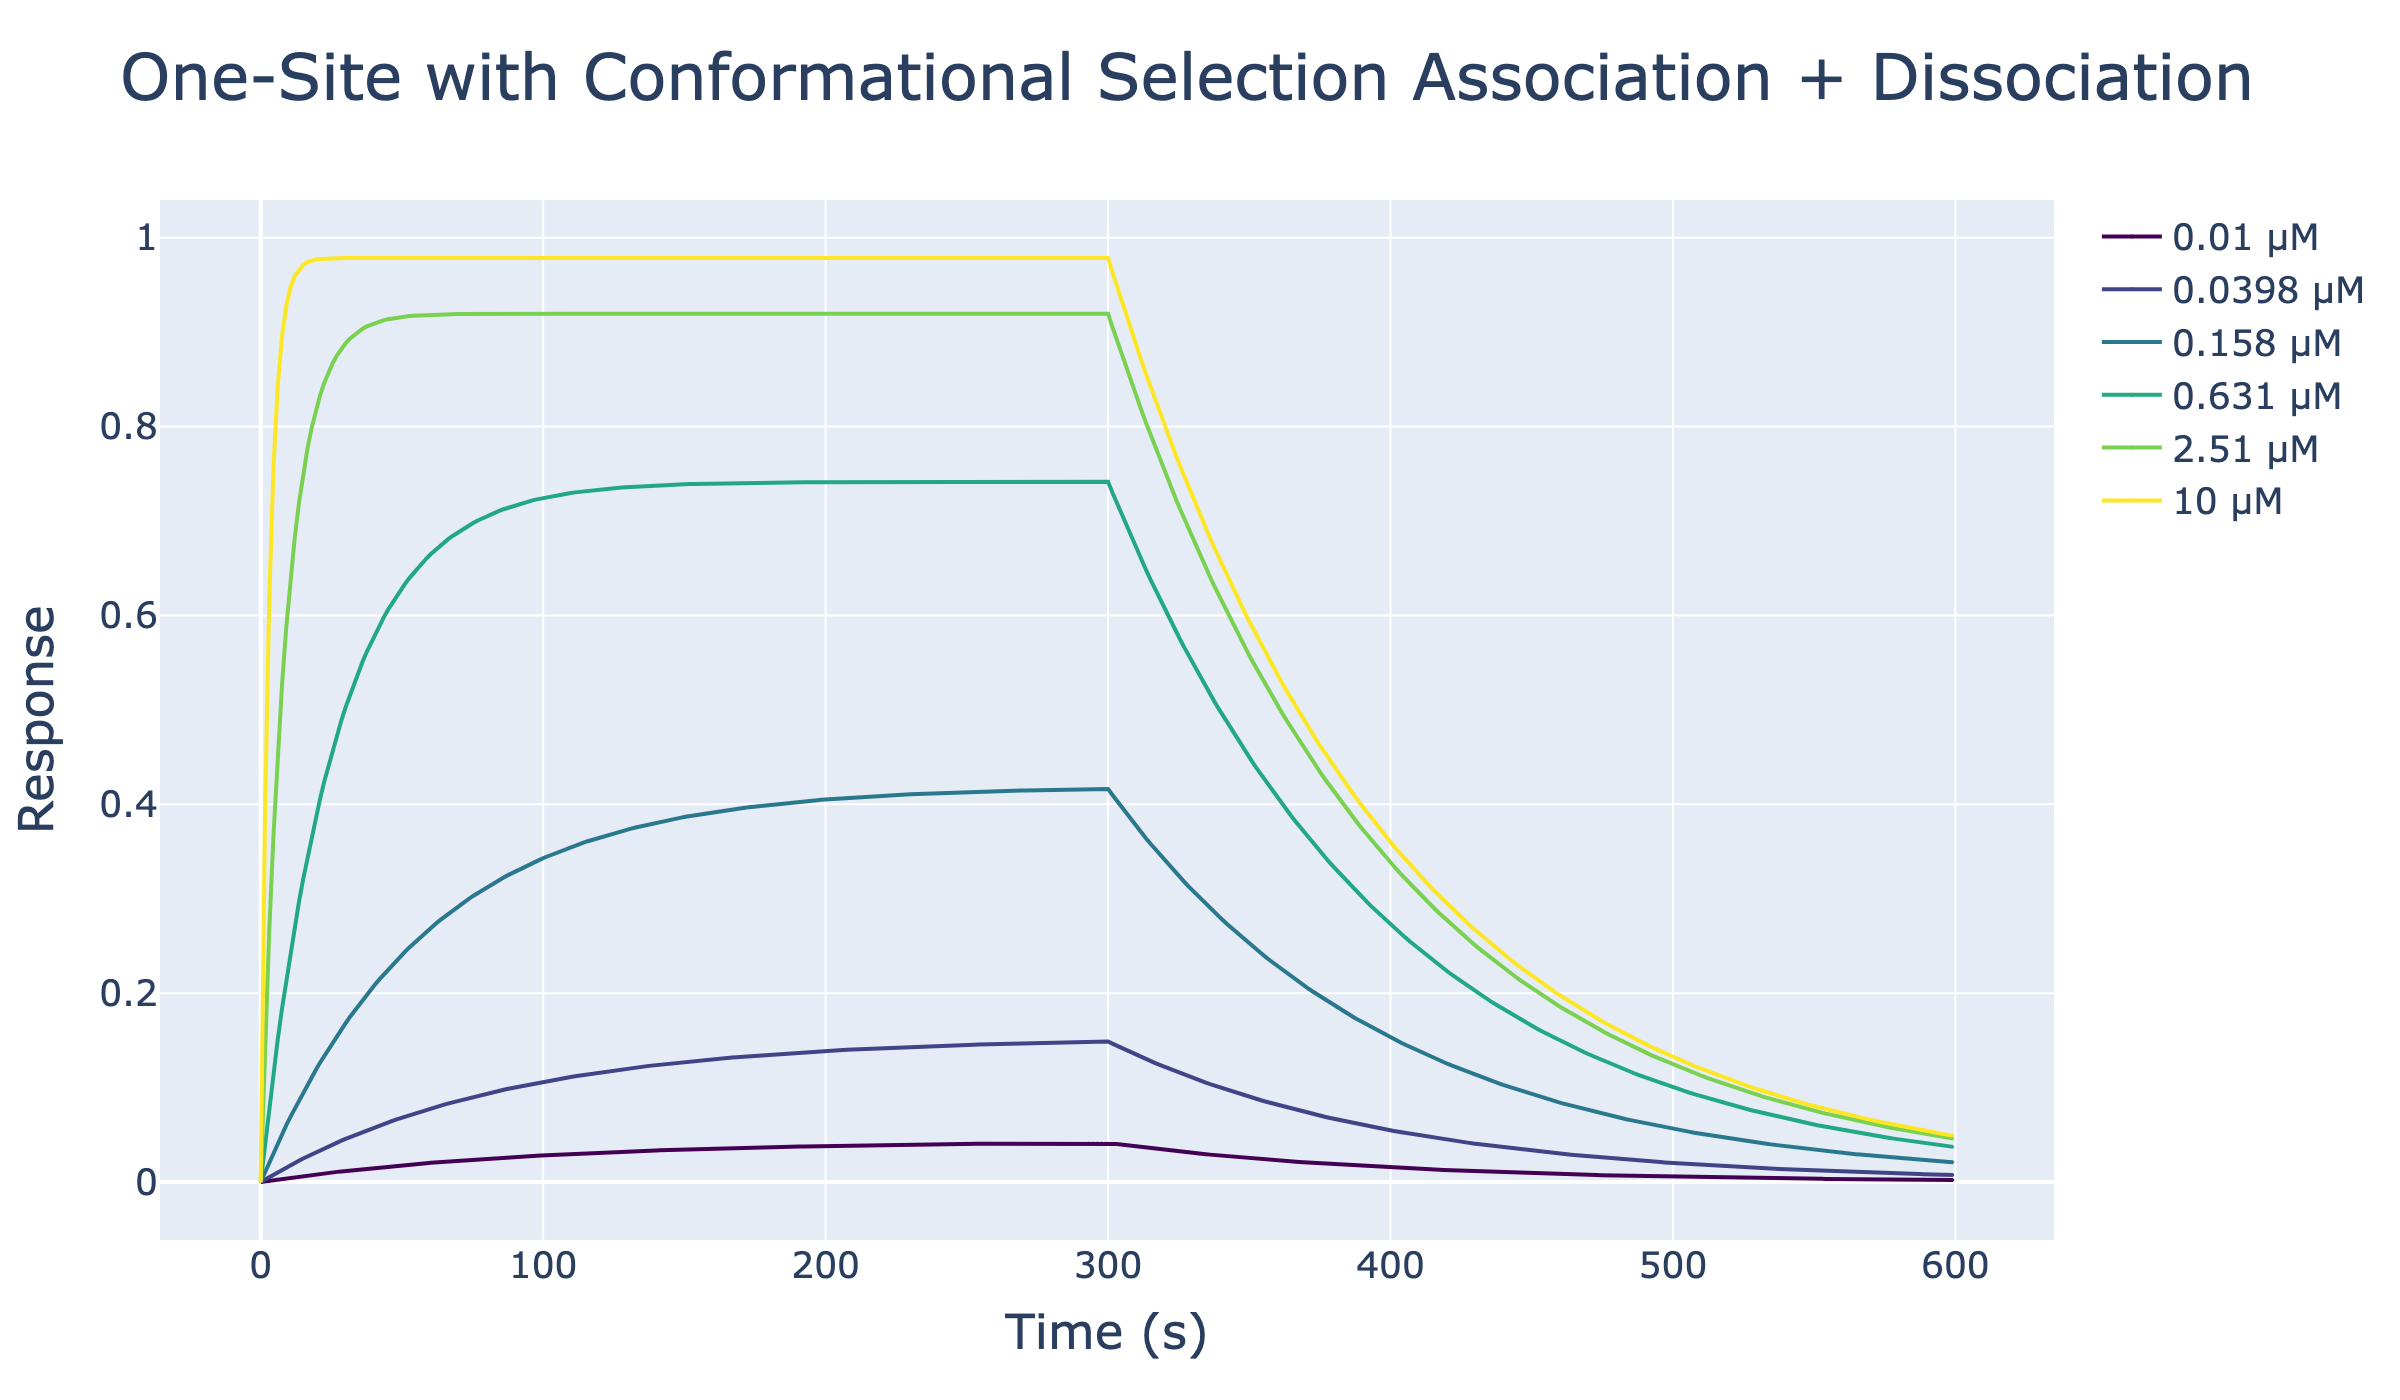

In [25]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "One-Site with Conformational Selection Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)